<a href="https://colab.research.google.com/github/djtheconqueror/home_ai/blob/main/BioSentinel_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scikit-learn pandas numpy matplotlib joblib --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay

In [2]:
rng = np.random.default_rng(42)
n = 500

data = pd.DataFrame({
    "persistence": rng.uniform(0, 1, n),
    "volatility": rng.uniform(0, 1, n),
    "detection_confidence": rng.uniform(0, 1, n),
    "toxicity_index": rng.uniform(0, 1, n),
    "anomaly_score": rng.uniform(0, 1, n),
})

risk_score = (
    0.30 * data["persistence"] +
    0.20 * data["volatility"] +
    0.25 * data["detection_confidence"] +
    0.15 * data["toxicity_index"] +
    0.10 * data["anomaly_score"]
)

data["is_threat"] = (risk_score > 0.6).astype(int)

data.head()

,persistence,volatility,detection_confidence,toxicity_index,anomaly_score,is_threat
0,0.773956,0.736706,0.062063,0.671854,0.842732,0
1,0.438878,0.886403,0.458262,0.960587,0.446389,1
2,0.858598,0.921057,0.129030,0.370912,0.952975,1
3,0.697368,0.503633,0.152327,0.425082,0.650795,0
4,0.094177,0.520275,0.632283,0.812123,0.115899,0


In [3]:
feature_cols = [
    "persistence",
    "volatility",
    "detection_confidence",
    "toxicity_index",
    "anomaly_score",
]

X = data[feature_cols]
y = data["is_threat"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        77
           1       1.00      0.70      0.82        23

    accuracy                           0.93       100
   macro avg       0.96      0.85      0.89       100
weighted avg       0.94      0.93      0.93       100

ROC AUC: 0.9954827780914738


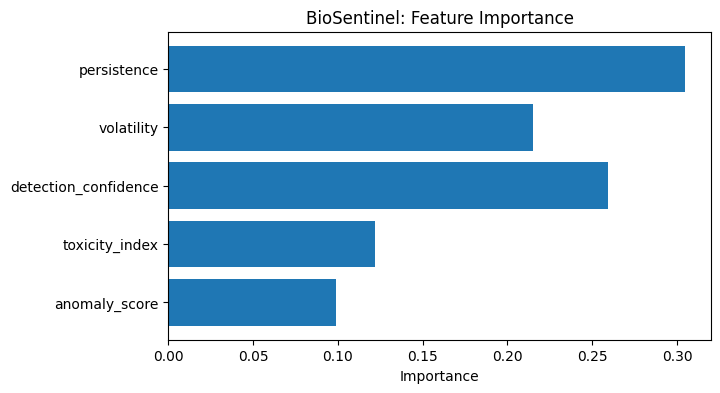

In [4]:
importances = model.feature_importances_

plt.figure(figsize=(7, 4))
plt.barh(feature_cols, importances)
plt.xlabel("Importance")
plt.title("BioSentinel: Feature Importance")
plt.gca().invert_yaxis()
plt.show()

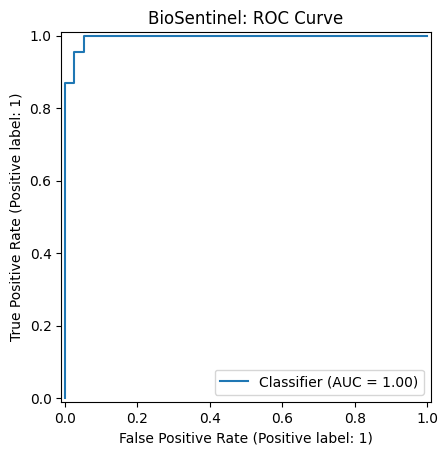

In [5]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("BioSentinel: ROC Curve")
plt.show()

In [11]:
def risk_level(prob, threshold=0.5):
    if prob >= 0.90:
        return "CRITICAL"
    elif prob >= 0.65:
        return "ELEVATED"
    elif prob >= 0.35:
        return "WATCH"
    else:
        return "LOW"


def biosentinel_score(sample_dict, threshold=0.5):
    x = pd.DataFrame([sample_dict])[feature_cols]

    prob = float(model.predict_proba(x)[0, 1])
    label = int(prob >= threshold)
    tier = risk_level(prob, threshold)

    bullets = [
        f"Global threat probability: {prob:.2%}",
        f"Decision threshold: {threshold:.2%}",
        f"Model decision: {'THREAT' if label else 'NO THREAT'}",
        f"Risk tier: {tier}",
    ]

    feature_comments = {
        "persistence": "Higher values suggest the signal remains active over time.",
        "volatility": "Measures instability or irregular changes in the signal.",
        "detection_confidence": "Indicates how strongly the system trusts the detection.",
        "toxicity_index": "Proxy for potential severity in the sample profile.",
        "anomaly_score": "Measures deviation from normal baseline behavior.",
    }

    for name, comment in feature_comments.items():
        bullets.append(f"{name}: {sample_dict[name]:.2f} — {comment}")

    explanation = {
        "summary": f"BioSentinel estimates a {prob:.1%} threat probability with {tier} risk.",
        "probability": prob,
        "label": label,
        "risk_level": tier,
        "bullets": bullets,
    }

    return prob, label, explanation


def biosentinel_report(sample_dict, name="Sample"):
    prob, label, explanation = biosentinel_score(sample_dict)

    print(f"=== BioSentinel Report: {name} ===")
    print(explanation["summary"])
    print()
    print("Decision:", "THREAT" if label == 1 else "NO THREAT")
    print("Risk level:", explanation["risk_level"])
    print()

    print("AI-style interpretation:")
    for bullet in explanation["bullets"]:
        print("•", bullet)

    df_sample = pd.DataFrame([sample_dict])[feature_cols]

    plt.figure(figsize=(7, 4))
    df_sample.T[0].plot(kind="bar")
    plt.title(f"Input Feature Profile — {name}")
    plt.ylabel("Value 0–1")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [6]:
def risk_level(prob, threshold=0.5):
    if prob >= 0.90:
        return "CRITICAL"
    elif prob >= threshold:
        return "ELEVATED"
    elif prob >= 0.35:
        return "WATCH"
    else:
        return "LOW"


def biosentinel_score(sample_dict, threshold=0.5):
    x = pd.DataFrame([sample_dict])[feature_cols]
    prob = float(model.predict_proba(x)[0, 1])
    label = int(prob >= threshold)
    tier = risk_level(prob, threshold)

    bullets = [
        f"Global threat probability: {prob:.2%}",
        f"Decision threshold: {threshold:.2%}",
        f"Model decision: {'THREAT' if label else 'NO THREAT'}",
        f"Risk tier: {tier}",
    ]

    feature_comments = {
        "persistence": "Higher values suggest the signal is sustained over time.",
        "volatility": "Measures how unstable or spiky the signal is.",
        "detection_confidence": "Indicates how strongly sensors trust the detection.",
        "toxicity_index": "Proxy for potential severity.",
        "anomaly_score": "Measures deviation from normal baseline behavior.",
    }

    for name, comment in feature_comments.items():
        bullets.append(f"{name}: {sample_dict[name]:.2f} — {comment}")

    explanation = {
        "summary": f"BioSentinel estimates a {prob:.1%} threat probability with {tier} risk.",
        "probability": prob,
        "label": label,
        "risk_level": tier,
        "bullets": bullets,
    }

    return prob, label, explanation

In [7]:
sample = {
    "persistence": 0.72,
    "volatility": 0.41,
    "detection_confidence": 0.86,
    "toxicity_index": 0.63,
    "anomaly_score": 0.58,
}

prob, label, explanation = biosentinel_score(sample)

print("=== BioSentinel Report ===")
print(explanation["summary"])
print()

for bullet in explanation["bullets"]:
    print("•", bullet)

=== BioSentinel Report ===
BioSentinel estimates a 48.8% threat probability with WATCH risk.

• Global threat probability: 48.82%
• Decision threshold: 50.00%
• Model decision: NO THREAT
• Risk tier: WATCH
• persistence: 0.72 — Higher values suggest the signal is sustained over time.
• volatility: 0.41 — Measures how unstable or spiky the signal is.
• detection_confidence: 0.86 — Indicates how strongly sensors trust the detection.
• toxicity_index: 0.63 — Proxy for potential severity.
• anomaly_score: 0.58 — Measures deviation from normal baseline behavior.


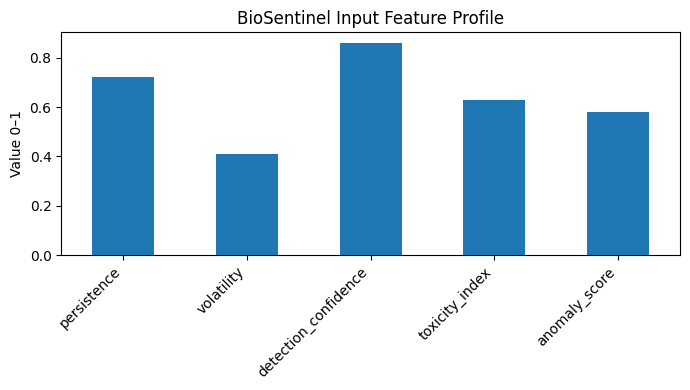

In [8]:
df_sample = pd.DataFrame([sample])[feature_cols]

plt.figure(figsize=(7, 4))
df_sample.T[0].plot(kind="bar")
plt.title("BioSentinel Input Feature Profile")
plt.ylabel("Value 0–1")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [9]:
artifact = {
    "model": model,
    "feature_cols": feature_cols,
    "threshold": 0.5,
}

joblib.dump(artifact, "biosentinel_rf.pkl")
print("Saved model as biosentinel_rf.pkl")

Saved model as biosentinel_rf.pkl


In [10]:
from google.colab import files
files.download("biosentinel_rf.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

=== BioSentinel Report: Signal A ===
BioSentinel estimates a 48.8% threat probability with WATCH risk.

Decision: NO THREAT
Risk level: WATCH

AI-style interpretation:
• Global threat probability: 48.82%
• Decision threshold: 50.00%
• Model decision: NO THREAT
• Risk tier: WATCH
• persistence: 0.72 — Higher values suggest the signal remains active over time.
• volatility: 0.41 — Measures instability or irregular changes in the signal.
• detection_confidence: 0.86 — Indicates how strongly the system trusts the detection.
• toxicity_index: 0.63 — Proxy for potential severity in the sample profile.
• anomaly_score: 0.58 — Measures deviation from normal baseline behavior.


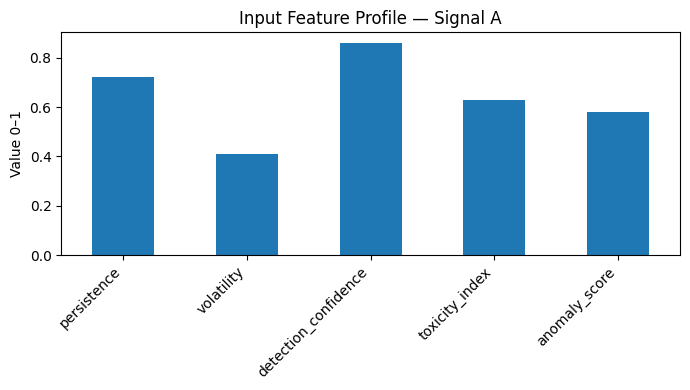

In [12]:
sample = {
    "persistence": 0.72,
    "volatility": 0.41,
    "detection_confidence": 0.86,
    "toxicity_index": 0.63,
    "anomaly_score": 0.58,
}

biosentinel_report(sample, name="Signal A")


=== BioSentinel Report: Low Concern Signal ===
BioSentinel estimates a 0.1% threat probability with LOW risk.

Decision: NO THREAT
Risk level: LOW

AI-style interpretation:
• Global threat probability: 0.10%
• Decision threshold: 50.00%
• Model decision: NO THREAT
• Risk tier: LOW
• persistence: 0.20 — Higher values suggest the signal remains active over time.
• volatility: 0.15 — Measures instability or irregular changes in the signal.
• detection_confidence: 0.30 — Indicates how strongly the system trusts the detection.
• toxicity_index: 0.20 — Proxy for potential severity in the sample profile.
• anomaly_score: 0.25 — Measures deviation from normal baseline behavior.


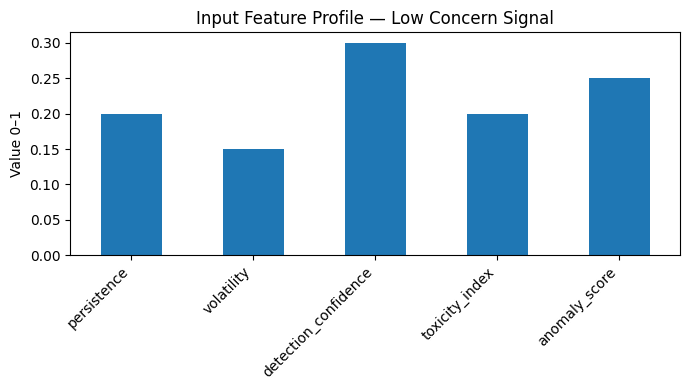

=== BioSentinel Report: Watchlist Signal ===
BioSentinel estimates a 2.9% threat probability with LOW risk.

Decision: NO THREAT
Risk level: LOW

AI-style interpretation:
• Global threat probability: 2.89%
• Decision threshold: 50.00%
• Model decision: NO THREAT
• Risk tier: LOW
• persistence: 0.45 — Higher values suggest the signal remains active over time.
• volatility: 0.50 — Measures instability or irregular changes in the signal.
• detection_confidence: 0.55 — Indicates how strongly the system trusts the detection.
• toxicity_index: 0.40 — Proxy for potential severity in the sample profile.
• anomaly_score: 0.50 — Measures deviation from normal baseline behavior.


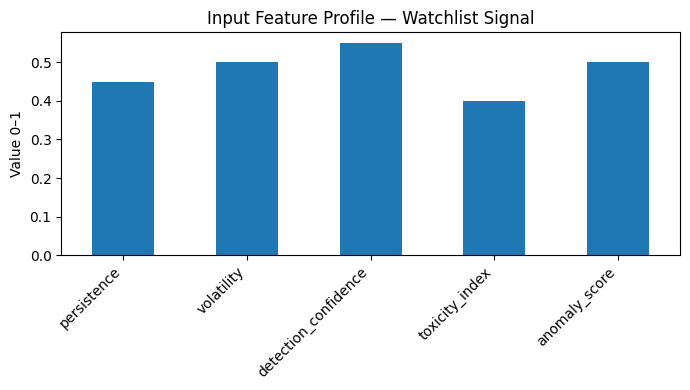

=== BioSentinel Report: High Concern Signal ===
BioSentinel estimates a 93.5% threat probability with CRITICAL risk.

Decision: THREAT
Risk level: CRITICAL

AI-style interpretation:
• Global threat probability: 93.45%
• Decision threshold: 50.00%
• Model decision: THREAT
• Risk tier: CRITICAL
• persistence: 0.82 — Higher values suggest the signal remains active over time.
• volatility: 0.68 — Measures instability or irregular changes in the signal.
• detection_confidence: 0.91 — Indicates how strongly the system trusts the detection.
• toxicity_index: 0.77 — Proxy for potential severity in the sample profile.
• anomaly_score: 0.84 — Measures deviation from normal baseline behavior.


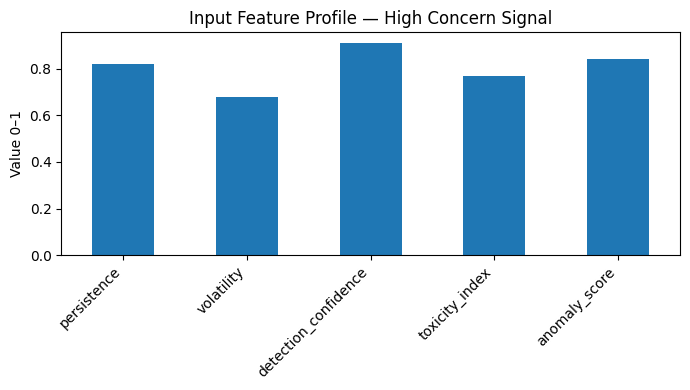

In [13]:
scenarios = {
    "Low Concern Signal": {
        "persistence": 0.20,
        "volatility": 0.15,
        "detection_confidence": 0.30,
        "toxicity_index": 0.20,
        "anomaly_score": 0.25,
    },
    "Watchlist Signal": {
        "persistence": 0.45,
        "volatility": 0.50,
        "detection_confidence": 0.55,
        "toxicity_index": 0.40,
        "anomaly_score": 0.50,
    },
    "High Concern Signal": {
        "persistence": 0.82,
        "volatility": 0.68,
        "detection_confidence": 0.91,
        "toxicity_index": 0.77,
        "anomaly_score": 0.84,
    },
}

for name, sample in scenarios.items():
    biosentinel_report(sample, name=name)

In [14]:
artifact = {
    "model": model,
    "feature_cols": feature_cols,
    "threshold": 0.5,
}

joblib.dump(artifact, "biosentinel_rf.pkl")

print("Saved model artifact: biosentinel_rf.pkl")

Saved model artifact: biosentinel_rf.pkl


In [15]:
import joblib

artifact = {
    "model": model,
    "feature_cols": feature_cols,
    "threshold": 0.5,
}

joblib.dump(artifact, "biosentinel_rf.pkl")

print("Saved model artifact: biosentinel_rf.pkl")

Saved model artifact: biosentinel_rf.pkl


In [16]:
from google.colab import files
files.download("biosentinel_rf.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>